In [13]:
import pandas as pd

In [20]:
df = pd.read_csv(r"/content/orders_export_day9.csv",on_bad_lines='skip')

In [24]:
print(df.head(10))

   Row_ID        Order_ID  Order_Date   Ship_Date  Shipping_Delay_Days  \
0    7469  CA-2014-138100  2014-09-15  2014-09-20                    5   
1    7470  CA-2014-138100  2014-09-15  2014-09-20                    5   
2    5200  CA-2016-103982  2016-03-03  2016-03-08                    5   
3    5199  CA-2016-103982  2016-03-03  2016-03-08                    5   
4    5201  CA-2016-103982  2016-03-03  2016-03-08                    5   
5    5202  CA-2016-103982  2016-03-03  2016-03-08                    5   
6    5202  CA-2016-103982  2016-03-03  2016-03-08                    5   
7    5201  CA-2016-103982  2016-03-03  2016-03-08                    5   
8    5199  CA-2016-103982  2016-03-03  2016-03-08                    5   
9    5200  CA-2016-103982  2016-03-03  2016-03-08                    5   

        Ship_Mode Customer_ID Customer_Name   Segment        Country  ...  \
0  Standard Class    AA-10315    Alex Avila  Consumer  United States  ...   
1  Standard Class    AA-10315  

In [22]:
print(df.shape)

(962, 26)


In [23]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 962 entries, 0 to 961
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Row_ID                    962 non-null    int64  
 1   Order_ID                  962 non-null    object 
 2   Order_Date                962 non-null    object 
 3   Ship_Date                 962 non-null    object 
 4   Shipping_Delay_Days       962 non-null    int64  
 5   Ship_Mode                 962 non-null    object 
 6   Customer_ID               962 non-null    object 
 7   Customer_Name             962 non-null    object 
 8   Segment                   962 non-null    object 
 9   Country                   962 non-null    object 
 10  City                      962 non-null    object 
 11  State                     962 non-null    object 
 12  Postal_Code               962 non-null    int64  
 13  Region                    962 non-null    object 
 14  Product_ID

In [25]:
print(df[['Sales','Profit','Discount']].describe())

             Sales       Profit    Discount
count   962.000000   962.000000  962.000000
mean    238.211164    40.664103    0.208740
std     630.141499   265.050016    1.102581
min       1.360000  -786.014400   -3.729600
25%      16.000000     1.090400    0.000000
50%      52.475000     7.742000    0.150000
75%     207.872500    32.500800    0.200000
max    9892.740000  4946.370000   21.445200


In [26]:
print(df[['Sales','Profit','Discount']].agg(['mean','median','std','min','max']))

              Sales       Profit   Discount
mean     238.211164    40.664103   0.208740
median    52.475000     7.742000   0.150000
std      630.141499   265.050016   1.102581
min        1.360000  -786.014400  -3.729600
max     9892.740000  4946.370000  21.445200


In [27]:
print(df[['Sales','Profit','Discount']].isnull().sum())

Sales       0
Profit      0
Discount    0
dtype: int64


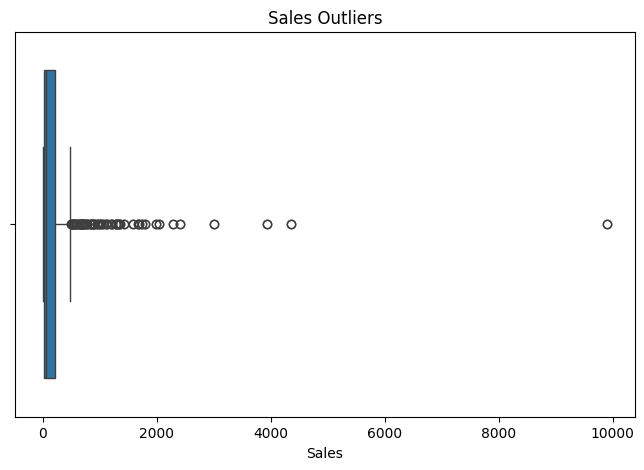

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x=df['Sales'])
plt.title("Sales Outliers")
plt.show()

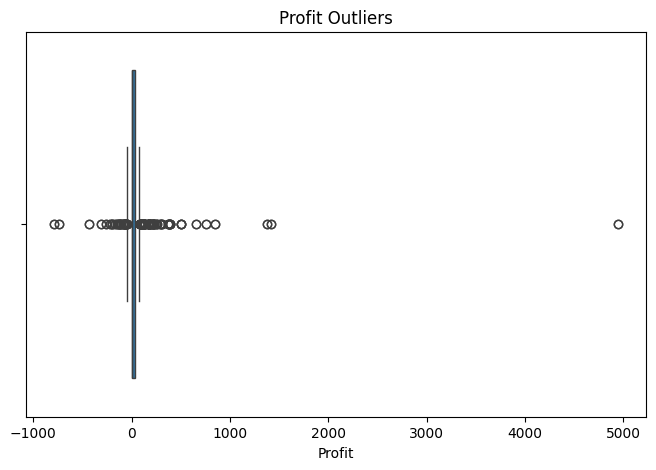

In [33]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Profit'])
plt.title("Profit Outliers")
plt.show()

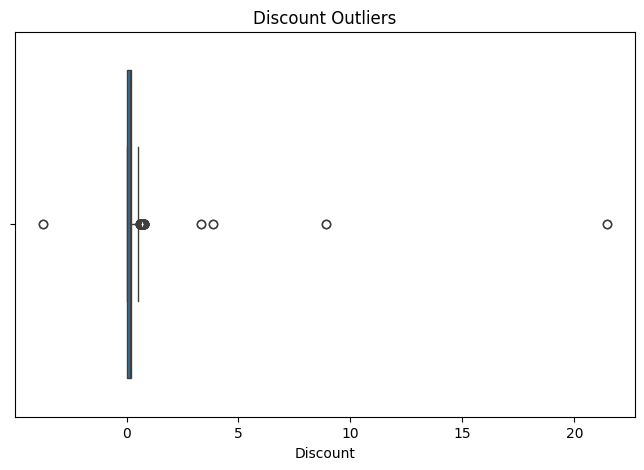

In [34]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Discount'])
plt.title("Discount Outliers")
plt.show()

In [35]:
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Sales'] < lower) | (df['Sales'] > upper)]

print("Outliers:", len(outliers))

Outliers: 108


In [36]:
df_clean = df[
    (df['Sales'] >= lower) &
    (df['Sales'] <= upper)
]

print(df_clean.shape)

(854, 26)


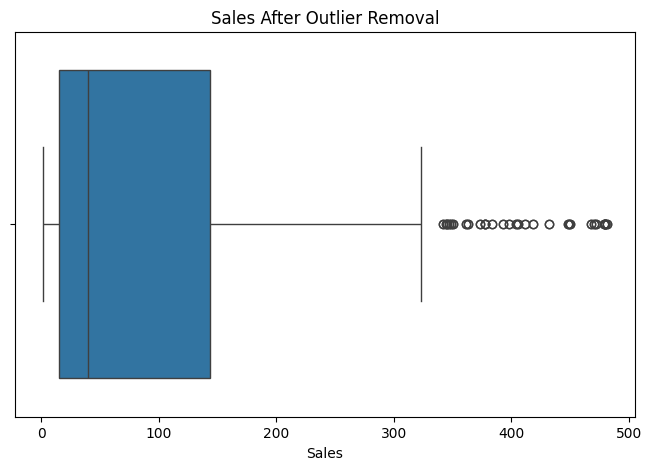

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x=df_clean['Sales'])
plt.title("Sales After Outlier Removal")
plt.show()